In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

import matplotlib.pyplot as plt

In [14]:
columns = [
    'engine_id',
    'cycle'
]

columns += [f'operational_setting_{i}' for i in range(1,4)]

columns += [f'sensor_{i}' for i in range(1,22)]

df = pd.read_csv(
    'train_FD001.txt',
    sep=r'\s+',
    header=None
)

df.columns = columns

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(20631, 26)

First 5 Rows:
   engine_id  cycle  operational_setting_1  operational_setting_2  \
0          1      1                -0.0007                -0.0004   
1          1      2                 0.0019                -0.0003   
2          1      3                -0.0043                 0.0003   
3          1      4                 0.0007                 0.0000   
4          1      5                -0.0019                -0.0002   

   operational_setting_3  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0                  100.0    518.67    641.82   1589.70   1400.60     14.62   
1                  100.0    518.67    642.15   1591.82   1403.14     14.62   
2                  100.0    518.67    642.35   1587.99   1404.20     14.62   
3                  100.0    518.67    642.35   1582.79   1401.87     14.62   
4                  100.0    518.67    642.37   1582.85   1406.22     14.62   

   ...  sensor_12  sensor_13  sensor_14  sensor_15  sensor_16  sensor_17  

In [15]:
max_cycles = df.groupby(
    'engine_id'
)['cycle'].max()

df = df.merge(
    max_cycles.rename('max_cycle'),
    on='engine_id'
)

df['RUL'] = (
    df['max_cycle']
    - df['cycle']
)

print("\nRUL Created Successfully")


RUL Created Successfully


In [16]:
X = df.drop(
    columns=[
        'engine_id',
        'cycle',
        'max_cycle',
        'RUL'
    ]
)

y = df['RUL']

print("\nFeature Matrix Shape:")
print(X.shape)


Feature Matrix Shape:
(20631, 24)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Model...")

model.fit(
    X_train,
    y_train
)

print("Training Complete!")


Training Model...
Training Complete!


In [19]:
predictions = model.predict(X_test)

In [20]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nMODEL PERFORMANCE")
print("-"*30)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


MODEL PERFORMANCE
------------------------------
MAE  : 29.69
RMSE : 41.52
R²   : 0.62


In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features")

print(
    importance.head(10)
)


Top Important Features
      Feature  Importance
13  sensor_11    0.401813
11   sensor_9    0.122583
6    sensor_4    0.121062
14  sensor_12    0.052464
9    sensor_7    0.037132
16  sensor_14    0.035848
23  sensor_21    0.032169
17  sensor_15    0.030902
5    sensor_3    0.027355
4    sensor_2    0.027044


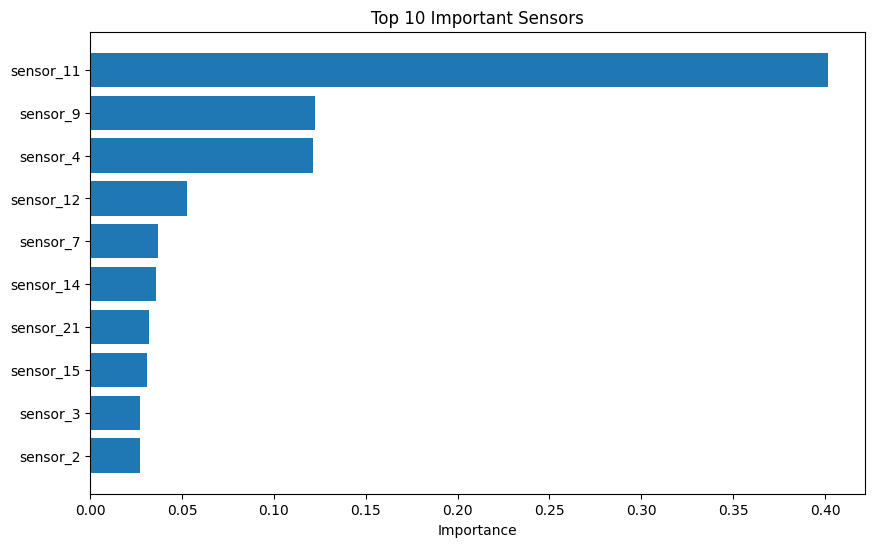

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    importance.head(10)['Feature'],
    importance.head(10)['Importance']
)

plt.title(
    'Top 10 Important Sensors'
)

plt.xlabel(
    'Importance'
)

plt.gca().invert_yaxis()

plt.show()

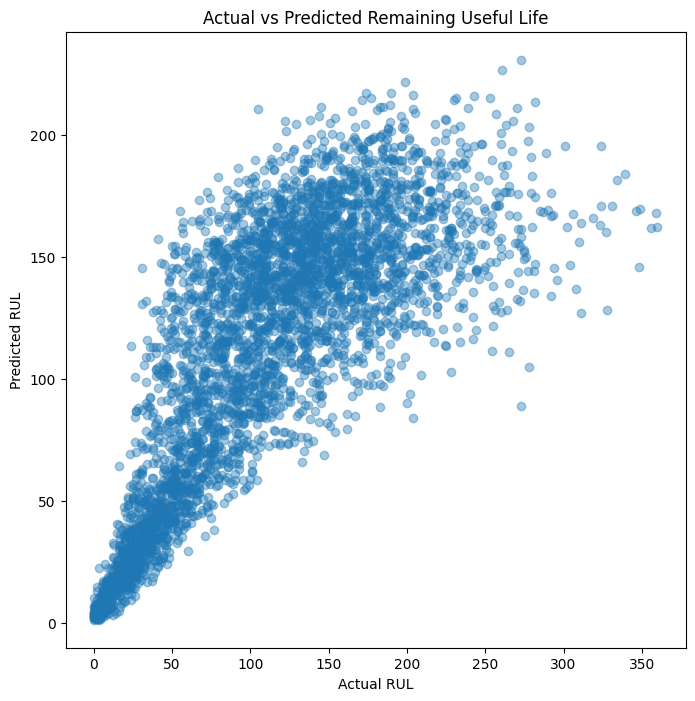

In [23]:

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.4
)

plt.xlabel(
    'Actual RUL'
)

plt.ylabel(
    'Predicted RUL'
)

plt.title(
    'Actual vs Predicted Remaining Useful Life'
)

plt.show()

In [24]:
sample_prediction = predictions[0]

print("\nMaintenance Recommendation")

if sample_prediction < 20:
    print("CRITICAL: Immediate Maintenance Required")

elif sample_prediction < 50:
    print("WARNING: Schedule Maintenance Soon")

else:
    print("HEALTHY: Engine Operating Normally")


Maintenance Recommendation
HEALTHY: Engine Operating Normally
